# 🔌 LG ThinQ Reddit 크롤링 & 텍스트 분석 노트북

이 노트북은 Reddit에서 LG ThinQ / 스마트홈 관련 게시글을 Reddit API(PRAW)로 수집 후 전처리/감성/워드클라우드/요약을 수행합니다.

프로세스:
1. 환경 변수 확인 (.env 또는 시스템) - REDDIT_CLIENT_ID / REDDIT_CLIENT_SECRET / REDDIT_USER_AGENT
2. 서브레딧 & 키워드 정의 (스마트홈, 가전)
3. Reddit API 크롤링
4. 전처리 + 토큰화(Okt or fallback)
5. 기본 감성(TextBlob + Lexicon) & 빈도/TF-IDF
6. 워드클라우드 & 서브레딧별 요약
7. 저장 및 재사용


In [1]:
# 1. 필요 라이브러리 설치 (이미 설치되어 있다면 무시)
import sys, subprocess, importlib
pkgs = ['praw','pandas','numpy','matplotlib','seaborn','wordcloud','konlpy','tqdm','textblob','scikit-learn','networkx']
for p in pkgs:
    try:
        importlib.import_module(p if p!='scikit-learn' else 'sklearn')
    except ImportError:
        print('Installing', p)
        subprocess.check_call([sys.executable,'-m','pip','install',p])


In [2]:
# 1-1. 임포트 & 환경변수 검사
import os, re, json, time, math, itertools, collections
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import networkx as nx

import praw

REQUIRED_ENV = ['REDDIT_CLIENT_ID','REDDIT_CLIENT_SECRET','REDDIT_USER_AGENT']
missing = [e for e in REQUIRED_ENV if not os.getenv(e)]
if missing:
    print('경고: 환경변수 누락 ->', missing, '(.env 또는 시스템 변수 설정 필요)')
else:
    print('Reddit API 환경변수 OK')

DATA_DIR = Path('data/lg_thinq')
DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_FILE = DATA_DIR/'reddit_thinq_posts.csv'


Reddit API 환경변수 OK


In [3]:
# 2. Reddit 크롤링 (LG ThinQ / 스마트홈)
USE_CRAWL = True  # 필요 시 False
SUBREDDITS = [
    'homeautomation','smarthome','HomeImprovement','appliances','LG_UserHub','technology'
]
QUERIES = [
    'LG ThinQ','ThinQ app','LG smart washer','LG smart refrigerator','LG ThinQ integration','LG ThinQ wifi'
]
LIMIT_PER_QUERY = 60
SLEEP = 1.0

from dataclasses import dataclass, asdict
@dataclass
class ThinQPost:
    id: str
    subreddit: str
    title: str
    selftext: str
    created_utc: float
    score: int
    num_comments: int
    permalink: str
    url: str
    combined_text: str


def build_client():
    if any([not os.getenv(k) for k in REQUIRED_ENV]):
        raise EnvironmentError('환경변수 부족. REDDIT_CLIENT_* 설정 필요')
    return praw.Reddit(
        client_id=os.environ['REDDIT_CLIENT_ID'],
        client_secret=os.environ['REDDIT_CLIENT_SECRET'],
        user_agent=os.environ['REDDIT_USER_AGENT'],
    )

posts = []
if USE_CRAWL:
    reddit = build_client()
    seen = set()
    for sub in SUBREDDITS:
        for q in QUERIES:
            try:
                results = reddit.subreddit(sub).search(q, limit=LIMIT_PER_QUERY, sort='new')
                for r in results:
                    if r.id in seen: continue
                    body = getattr(r,'selftext','') or ''
                    posts.append(ThinQPost(
                        id=r.id,
                        subreddit=sub,
                        title=r.title.strip(),
                        selftext=body.strip(),
                        created_utc=float(getattr(r,'created_utc',0.0)),
                        score=int(getattr(r,'score',0)),
                        num_comments=int(getattr(r,'num_comments',0)),
                        permalink=f"https://reddit.com{r.permalink}",
                        url=getattr(r,'url',''),
                        combined_text=(r.title+'\n'+body).strip()
                    ))
                    seen.add(r.id)
                time.sleep(SLEEP)
            except Exception as e:
                print('[WARN]', sub, q, e)
else:
    print('크롤링 비활성화. 기존 CSV 로드 예정.')

if posts:
    df = pd.DataFrame([asdict(p) for p in posts])
    df.to_csv(RAW_FILE, index=False, encoding='utf-8-sig')
    print('크롤링 수집 행:', len(df), '→', RAW_FILE)
else:
    if RAW_FILE.exists():
        df = pd.read_csv(RAW_FILE)
        print('기존 파일 로드:', RAW_FILE, df.shape)
    else:
        df = pd.DataFrame(columns=['id','subreddit','title','selftext','combined_text'])
        print('데이터 없음(크롤링 필요).')

df.head(3)

크롤링 수집 행: 729 → data\lg_thinq\reddit_thinq_posts.csv


,id,subreddit,title,selftext,created_utc,score,num_comments,permalink,url,combined_text
0,1i5zgvp,homeautomation,Customize a program on the LG Washer and Dryer.,"Hello Everyone, \n\nI bought a machine, and I ...",1.737403e+09,4,1,https://reddit.com/r/homeautomation/comments/1...,https://www.reddit.com/r/homeautomation/commen...,Customize a program on the LG Washer and Dryer...
1,1hjfd76,homeautomation,LG ThinQ Hood Alexa Integration,"I can add many LG ThinQ appliances to Alexa, b...",1.734804e+09,3,1,https://reddit.com/r/homeautomation/comments/1...,https://www.reddit.com/r/homeautomation/commen...,LG ThinQ Hood Alexa Integration\nI can add man...
2,1hh33u3,homeautomation,I've added washer and dryer to ThinQ but it's ...,I have successfully connected both my washer a...,1.734533e+09,1,2,https://reddit.com/r/homeautomation/comments/1...,https://www.reddit.com/r/homeautomation/commen...,I've added washer and dryer to ThinQ but it's ...


[INFO] Okt 실패 → fallback: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


Tokenizing: 100%|██████████| 729/729 [00:00<00:00, 9464.00it/s]

Sentiment counts:
 sentiment
positive    445
neutral     214
negative     70
Name: count, dtype: int64



C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df.head(30), y='word', x='count', palette='viridis')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:94: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:94: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:94: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:94: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_l

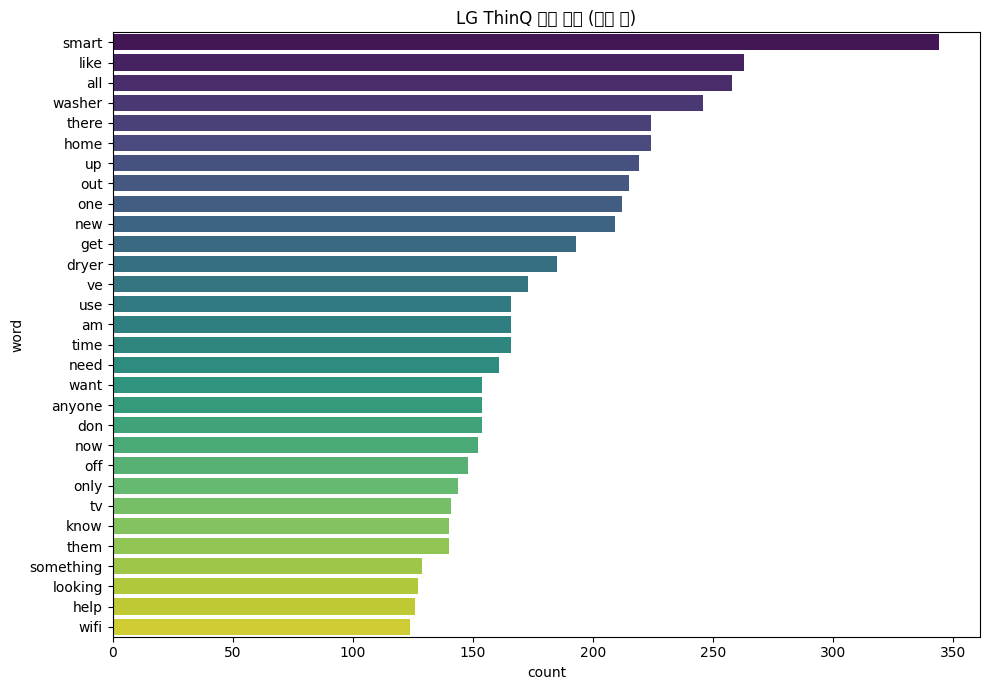

Saved bar -> data\lg_thinq\freq_bar.png


C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:106: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(WC_FILE, dpi=140, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:106: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.savefig(WC_FILE, dpi=140, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:106: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.savefig(WC_FILE, dpi=140, bbox_inches='tight')


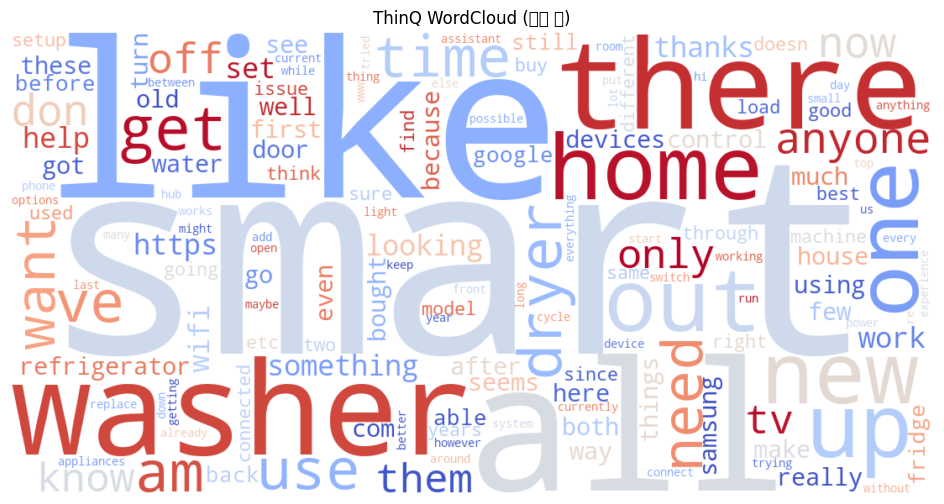

Saved wc -> data\lg_thinq\wordcloud.png


C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:119: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(outp, dpi=140, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:119: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.savefig(outp, dpi=140, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5544\151891915.py:119: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.savefig(outp, dpi=140, bbox_inches='tight')


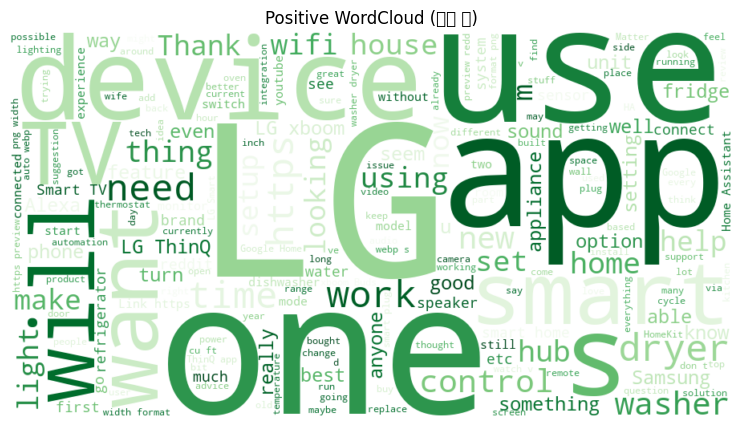

Saved -> data\lg_thinq\positive_wordcloud.png


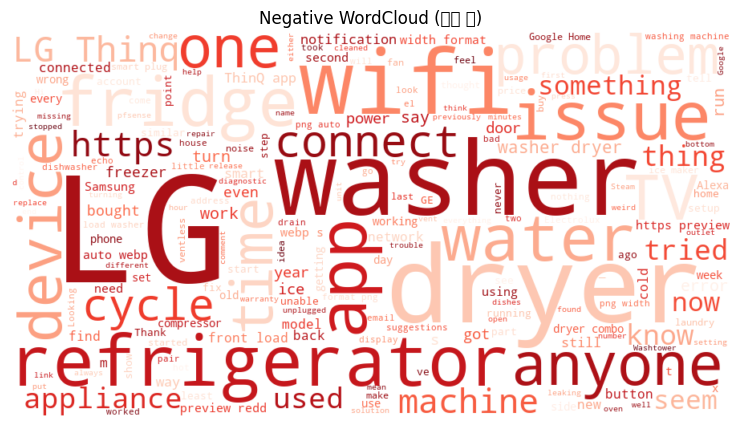

Saved -> data\lg_thinq\negative_wordcloud.png
Saved outputs -> data\lg_thinq\analysis


In [7]:
# 3. 전처리/토큰화/감성/분석
import re
if 'combined_text' not in df.columns:
    df['combined_text'] = (df.get('title','')+'\n'+df.get('selftext','')).fillna('').str.strip()

CLEAN_PATTERN = re.compile(r'[^0-9A-Za-z가-힣\s]')
MULTI = re.compile(r'\s+')

# ---------- Cleaning Function ----------
def basic_clean(t:str):
    t = t.lower()
    t = CLEAN_PATTERN.sub(' ', t)
    t = MULTI.sub(' ', t).strip()
    return t

df['cleaned'] = df['combined_text'].astype(str).map(basic_clean)

# ---------- Tokenizer (Okt or fallback) ----------
try:
    from konlpy.tag import Okt
    _okt = Okt(); USE_OKT=True
except Exception as e:
    print('[INFO] Okt 실패 → fallback:', e); USE_OKT=False

# Expanded multilingual stopwords
EN_STOP = {
    'the','a','an','to','for','of','on','in','and','or','is','are','be','it','its','this','that','with','from','by','at','as','was','were','have','has','had','can','will','should','could','would','not','just','so','if','but','about','into','over','than','then','when','where','how','why','what','which','who','whom','your','you','i','me','my','we','they','their','our','ours','yours','rt','via','amp','do','does','did','done','having','been','any','some','more','most','other','such','no','nor','too','very','also'
}
KO_STOP = {
    '것','거','수','등','및','더','이','저','하다','했다','하는','으로','있다','없는','및','등','수','것','더','다가','까지','이미','또','또한','하지만','그러나','그래서','그리고','거나','에서','하게','하게되','하지','하며','하면','하면되','있는','없는','합니다','했다','됩니다','되다','된다','하는','하며','하여','위해'
}
CUSTOM_STOP = {'thinq','lg','app'}
STOPWORDS = EN_STOP | KO_STOP | CUSTOM_STOP

SPLIT = re.compile(r'\s+')

def tokenize(doc:str):
    if USE_OKT:
        toks = _okt.nouns(doc)
    else:
        toks = [w for w in SPLIT.split(doc) if w]
    # keep only alphanumeric/hangul, length>1, not stop, not pure digits
    out=[]
    for w in toks:
        if len(w) < 2: continue
        if w in STOPWORDS: continue
        if w.isdigit(): continue
        out.append(w)
    return out

def normalize_tokens(toks):
    seen=set(); res=[]
    for w in toks:
        if w in seen: continue
        seen.add(w); res.append(w)
    return res

from tqdm import tqdm
df['tokens'] = [normalize_tokens(tokenize(t)) for t in tqdm(df['cleaned'], desc='Tokenizing')]

# ---------- Sentiment (TextBlob + simple lexicon) ----------
pos_lex = {'easy','useful','stable','fast','good','great','love','smooth','integrate','reliable','helpful','efficient'}
neg_lex = {'problem','issue','error','fail','disconnect','slow','crash','bug','lag','broken','annoying'}

def sentiment(t:str):
    blob = TextBlob(t)
    pol = blob.sentiment.polarity
    low = t.lower()
    pol += 0.05*sum(1 for w in pos_lex if w in low)
    pol -= 0.05*sum(1 for w in neg_lex if w in low)
    if pol>0.07: s='positive'
    elif pol<-0.07: s='negative'
    else: s='neutral'
    return s, pol

if 'sentiment' not in df.columns:
    sent_res = df['combined_text'].apply(sentiment)
    df['sentiment'] = [s for s,_ in sent_res]
    df['polarity'] = [p for _,p in sent_res]

print('Sentiment counts:\n', df['sentiment'].value_counts())

# ---------- Frequency ----------
from collections import Counter
all_toks = list(itertools.chain.from_iterable(df['tokens']))
freq = Counter(all_toks)
TOP = 40
freq_df = pd.DataFrame(freq.most_common(TOP), columns=['word','count'])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.barplot(data=freq_df.head(30), y='word', x='count', palette='viridis')
plt.title('LG ThinQ 단어 빈도 (정제 후)')
plt.tight_layout()
BAR_FILE = DATA_DIR/'freq_bar.png'
plt.savefig(BAR_FILE, dpi=140)
plt.show()
print('Saved bar ->', BAR_FILE)

# ---------- WordCloud ----------
from wordcloud import WordCloud
wc = WordCloud(width=1100,height=550, background_color='white', colormap='coolwarm').generate_from_frequencies(dict(freq.most_common(150)))
plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.title('ThinQ WordCloud (정제 후)')
WC_FILE = DATA_DIR/'wordcloud.png'
plt.savefig(WC_FILE, dpi=140, bbox_inches='tight')
plt.show()
print('Saved wc ->', WC_FILE)

# ---------- Sentiment WordClouds ----------
for label, cmap in [('positive','Greens'),('negative','Reds')]:
    subset = df.loc[df.sentiment==label,'combined_text']
    if subset.empty: continue
    txt = ' '.join(subset)
    sub_wc = WordCloud(width=900,height=480, background_color='white', colormap=cmap).generate(txt)
    plt.figure(figsize=(10,5))
    plt.imshow(sub_wc, interpolation='bilinear'); plt.axis('off'); plt.title(f'{label.title()} WordCloud (정제 후)')
    outp = DATA_DIR/f'{label}_wordcloud.png'
    plt.savefig(outp, dpi=140, bbox_inches='tight')
    plt.show(); print('Saved ->', outp)

# ---------- Save Outputs ----------
OUT_BASE = DATA_DIR/'analysis'
OUT_BASE.mkdir(exist_ok=True)
freq_df.to_csv(OUT_BASE/'word_frequency.csv', index=False, encoding='utf-8-sig')
df.to_csv(OUT_BASE/'processed_posts.csv', index=False, encoding='utf-8-sig')
with open(OUT_BASE/'tokens.json','w', encoding='utf-8') as f: json.dump(df['tokens'].tolist(), f, ensure_ascii=False)
print('Saved outputs ->', OUT_BASE)